# 3.7 "찐" Multi-Agent System (feat. create_react_agent)

- 도구들을 활용하는 에이전트들이 협업하는 과정을 구현합니다

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o",
)

small_llm = ChatOpenAI(
    model="gpt-4o-mini",
)

In [3]:
%pip install --upgrade --quiet  yfinance


[notice] A new release of pip is available: 25.0 -> 26.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
from langgraph.graph import MessagesState
from langgraph.types import Command
from typing import Literal
from langchain_core.messages import HumanMessage
from langchain_community.tools.yahoo_finance_news import YahooFinanceNewsTool

from langchain.agents import create_agent
from langchain_community.agent_toolkits.polygon.toolkit import PolygonToolkit
from langchain_community.utilities.polygon import PolygonAPIWrapper

# POLYGON_API_KEY가 있으면 Polygon 도구 사용, 없으면 Yahoo Finance만 사용
polygon_api_key = os.getenv("POLYGON_API_KEY", "").strip()
if polygon_api_key:
    polygon = PolygonAPIWrapper(polygon_api_key=polygon_api_key)
    toolkit = PolygonToolkit.from_polygon_api_wrapper(polygon)
    polygon_tools = toolkit.get_tools()
    market_research_tools = [YahooFinanceNewsTool()] + polygon_tools
else:
    # .env에 POLYGON_API_KEY를 넣으면 Polygon 도구 추가 (https://polygon.io 무료 발급)
    market_research_tools = [YahooFinanceNewsTool()]

# 시장 조사 에이전트를 생성합니다.
market_research_agent = create_agent(
    model=llm,
    tools=market_research_tools,
    system_prompt='You are a market researcher. Provide fact only not opinions'
)

def market_research_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    """
    시장 조사 node입니다. 주어진 state를 기반으로 시장 조사 에이전트를 호출하고,
    결과를 supervisor node로 전달합니다.

    Args:
        state (MessagesState): 현재 메시지 상태를 나타내는 객체입니다.

    Returns:
        Command: supervisor node로 이동하기 위한 명령을 반환합니다.
    """
    # 시장 조사 에이전트를 호출하여 결과를 얻습니다.
    result = market_research_agent.invoke(state)
    
    # 결과 메시지를 업데이트하고 supervisor node로 이동합니다.
    return Command(
        update={'messages': [HumanMessage(content=result['messages'][-1].content, name='market_research')]},
        goto='supervisor'
    )

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [5]:
import yfinance as yf

from langchain.tools import tool

@tool
def get_stock_price(ticker: str) -> dict:
    """Given a stock ticker, return the price data for the past month"""
    stock_info = yf.download(ticker, period='1mo').to_dict()
    return stock_info


stock_research_tools = [get_stock_price]
stock_research_agent = create_agent(
    model=llm,
    tools=stock_research_tools,
    system_prompt='You are a stock researcher. Provide facts only not opinions'
)

def stock_research_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    """
    주식 조사 node입니다. 주어진 State를 기반으로 주식 조사 에이전트를 호출하고,
    결과를 supervisor node로 전달합니다.

    Args:
        state (MessagesState): 현재 메시지 상태를 나타내는 객체입니다.

    Returns:
        Command: supervisor node로 이동하기 위한 명령을 반환합니다.
    """
    result = stock_research_agent.invoke(state)

    return Command(
        update={'messages': [HumanMessage(content=result['messages'][-1].content, name='stock_research')]},
        goto='supervisor'
    )

In [6]:
@tool
def company_research_tool(ticker: str) -> dict:
    """Given a ticker, return the financial information and SEC filings"""
    company_info = yf.Ticker(ticker)
    financial_info = company_info.get_financials()
    sec_filings = company_info.get_sec_filings()
    return {
        'financial_info': financial_info,
        'sec_filings': sec_filings
    }

company_research_tools = [company_research_tool]
company_research_agent = create_agent(
    model=llm,
    tools=company_research_tools,
    system_prompt='You are a company researcher. Provide facts only not opinions'
)

def company_research_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    """
    회사 조사 node입니다. 주어진 State를 기반으로 회사 조사 에이전트를 호출하고,
    결과를 supervisor node로 전달합니다.

    Args:
        state (MessagesState): 현재 메시지 상태를 나타내는 객체입니다.

    Returns:
        Command: supervisor node로 이동하기 위한 명령을 반환합니다.
    """
    result = company_research_agent.invoke(state)

    return Command(
        update={'messages': [HumanMessage(content=result['messages'][-1].content, name='company_research')]},
        goto='supervisor'
    )

In [7]:
from langchain_core.prompts import PromptTemplate

analyst_prompt = PromptTemplate.from_template(
    """You are a stock market analyst. Given the following information, 
Please decide wheter to buy, sell, or hold the stock.

Information:
{messages}"""
)

analyst_chain = analyst_prompt | llm

def analyst_node(state: MessagesState):
    """
    분석가 node입니다. 주어진 State를 기반으로 분석가 체인을 호출하고,
    결과 메시지를 반환합니다.

    Args:
        state (MessagesState): 현재 메시지 상태를 나타내는 객체입니다.

    Returns:
        dict: 분석 결과 메시지를 포함하는 딕셔너리를 반환합니다.
    """
    result = analyst_chain.invoke({'messages': state['messages'][1:]})

    return {'messages': [result]}

- `supervisor`가 회사의 매니저와 유사한 역할을 하면서, 각 에이전트들의 결과를 종합하여 작업이 끝났는지 판단합니다

In [8]:
from typing import Literal
from typing_extensions import TypedDict

from langgraph.graph import MessagesState, END
from langgraph.types import Command


members = ["market_research", "stock_research", "company_research"]
options = members + ["FINISH"]

system_prompt = (
    "You are a supervisor tasked with managing a conversation between the"
    f" following workers: {members}. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH."
)


class Router(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH."""

    next: Literal[*options]



def supervisor_node(state: MessagesState) -> Command[Literal[*members, "analyst"]]:
    """
    supervisor node입니다. 주어진 State를 기반으로 각 worker의 결과를 종합하고,
    다음에 수행할 worker를 결정합니다. 모든 작업이 완료되면 analyst node로 이동합니다.

    Args:
        state (MessagesState): 현재 메시지 상태를 나타내는 객체입니다.

    Returns:
        Command: 다음에 수행할 worker 또는 analyst node로 이동하기 위한 명령을 반환합니다.
    """
    messages = [
        {"role": "system", "content": system_prompt},
    ] + state["messages"]
    response = llm.with_structured_output(Router).invoke(messages)
    goto = response["next"]
    if goto == "FINISH":
        goto = "analyst"

    return Command(goto=goto)

- `node`를 추가하고 `edge`로 연결합니다

In [9]:
from langgraph.graph import StateGraph, START

graph_builder = StateGraph(MessagesState)

graph_builder.add_node("supervisor", supervisor_node)
graph_builder.add_node("market_research", market_research_node)
graph_builder.add_node("stock_research", stock_research_node)
graph_builder.add_node("company_research", company_research_node)
graph_builder.add_node("analyst", analyst_node)

In [10]:
graph_builder.add_edge(START, "supervisor")
graph_builder.add_edge("analyst", END)
graph = graph_builder.compile()


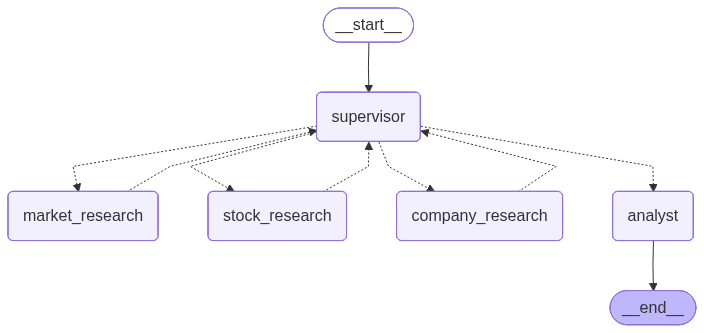

In [11]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


In [12]:
for chunk in graph.stream(
    {"messages": [("user", "Would you invest in Snowflake?")]}, stream_mode="values"
):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

Would you invest in Snowflake?
================================ Human Message =================================
Name: company_research

Here is some financial information and recent SEC filings for Snowflake (Ticker: SNOW):

### Financial Information (for fiscal year ending January 31, 2025)
- **Total Revenue:** $3.63 billion
- **Gross Profit:** $2.41 billion
- **Operating Income:** -$1.46 billion (loss)
- **Net Income:** -$1.29 billion (loss)
- **EBITDA:** -$1.10 billion (loss)
- **Research and Development Expenses:** $1.78 billion
- **Selling, General, and Administrative Expenses:** $2.08 billion
- **Cost of Revenue:** $1.21 billion
- **Total Expenses:** $5.08 billion
- **Diluted Earnings Per Share (EPS):** -$3.86 (loss)

### Recent SEC Filings
1. **8-K (Corporate Changes & Voting Matters):** Filed on February 2, 2026.
   - [Link to Filing](https://finance.yahoo.com/sec-filing/SNOW/0001628280-26-004606_

ValueError: API Error: {'status': 'NOT_AUTHORIZED', 'request_id': '24b8df8dd181efb9868a7d7ed20d7a54', 'message': 'You are not entitled to this data. Please upgrade your plan at https://polygon.io/pricing'}